In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import urllib.request
import random

In [3]:
url = "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=(reviewed:true)%20AND%20(organism_id:9606)"
fasta_file = "uniprot_human_reviewed.fasta"
output_file = "human_proteins.txt"

urllib.request.urlretrieve(url, fasta_file)

sequences = []
current_seq = []

with open(fasta_file, "r") as f:

    for line in f:
        line = line.strip()
        if line.startswith(">"):
            if current_seq:
                sequences.append("".join(current_seq))
                current_seq = []
        else:
            current_seq.append(line)

if current_seq:
    sequences.append("".join(current_seq))

with open(output_file, "w") as f:
    for seq in sequences:
        f.write(seq + "\n")


In [22]:
sequences = open('human_proteins.txt', 'r').read().splitlines()


In [4]:
chars = sorted(list(set(''.join(sequences))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}


In [ ]:
#Build Dataset

def build_dataset(sequences):
    block_size = 10
    total_samples = sum(len(seq) + 1 for seq in sequences)

    X = np.zeros((total_samples, block_size), dtype=np.int64)
    Y = np.zeros(total_samples, dtype=n
    idx = 0
    for sequence in sequences:
        context = [0] * block_size
        for char in sequence + '.':
            ix = stoi[char]
            X[idx] = context
            Y[idx] = ix
            context = context[1:] + [ix]
            idx += 1

    return torch.from_numpy(X), torch.from_numpy(Y)

random.shuffle(sequences)
n1 = int(len(sequences) * .8)
n2 = int(len(sequences) * .9)
X_train, Y_train = build_dataset(sequences[:n1])
X_dev, Y_dev = build_dataset(sequences[n1:n2])
X_test, Y_test = build_dataset(sequences[n2:])

In [6]:
#Training Set
X_train, Y_train, X_train.shape, Y_train.shape

(tensor([[ 0,  0,  0,  ...,  0,  0,  0],
         [ 0,  0,  0,  ...,  0,  0, 11],
         [ 0,  0,  0,  ...,  0, 11, 15],
         ...,
         [12,  8, 12,  ...,  8, 13,  4],
         [ 8, 12, 20,  ..., 13,  4, 10],
         [12, 20, 16,  ...,  4, 10, 14]]),
 tensor([11, 15, 13,  ..., 10, 14,  0]),
 torch.Size([9102265, 10]),
 torch.Size([9102265]))

In [7]:
vocab_size = len(stoi)
emb_dim = 16
block_size = 10

In [21]:
#Parameters
C = torch.randn((vocab_size, emb_dim))
W1 = torch.randn((block_size * emb_dim, 300)) * (5 / 3) / ((block_size * emb_dim) ** .5)
b1 = torch.randn(300)
W2 = torch.randn((300, vocab_size)) * 0.01
b2 = torch.zeros(vocab_size)
parameters = [C, W1, b1, W2, b2]

In [22]:
for param in parameters:
    param.requires_grad = True


In [ ]:
#Gradient Descent

for i in range(50000):

    #Minibatch
    batch_size = 128
    ix = torch.randint(0, X_train.shape[0], (batch_size,))

    #Forward pass
    emb = C[X_train[ix]]
    h = torch.tanh(emb.reshape(-1, emb_dim * block_size) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y_train[ix])

    #Backward pass
    for param in parameters:
        param.grad = None
    loss.backward()

    #Update parameters
    lr = .1
    for param in parameters:
        param.data += -lr * param.grad

    #Track cost
    if i % 1000 == 0:
        print(f'Cost after iteration {i}: {loss.item()}')



Cost after iteration 0: 2.8972301483154297
Cost after iteration 1000: 2.7854902744293213
Cost after iteration 2000: 2.8250069618225098
Cost after iteration 3000: 2.839264154434204
Cost after iteration 4000: 2.8151214122772217
Cost after iteration 5000: 2.808706521987915
Cost after iteration 6000: 2.8411309719085693
Cost after iteration 7000: 2.8375566005706787
Cost after iteration 8000: 2.80207896232605
Cost after iteration 9000: 2.885981798171997
Cost after iteration 10000: 2.825500011444092
Cost after iteration 11000: 2.8288700580596924
Cost after iteration 12000: 2.87678861618042
Cost after iteration 13000: 2.837394952774048
Cost after iteration 14000: 2.857123851776123
Cost after iteration 15000: 2.801682949066162
Cost after iteration 16000: 2.8405888080596924
Cost after iteration 17000: 2.816181182861328
Cost after iteration 18000: 2.803051471710205
Cost after iteration 19000: 2.8004701137542725
Cost after iteration 20000: 2.8174819946289062
Cost after iteration 21000: 2.851512670

In [27]:
#Testing on training and dev set
@torch.no_grad()
def evaluate_split(split_x, split_y, batch_size=10000):
    total_loss = 0.0
    num_samples = 0

    for i in range(0, split_x.shape[0], batch_size):
        Xb = split_x[i:i+batch_size]
        Yb = split_y[i:i+batch_size]

        emb = C[Xb]
        h = torch.tanh(emb.reshape(-1, emb_dim * block_size) @ W1 + b1)
        logits = h @ W2 + b2
        loss = F.cross_entropy(logits, Yb)

        total_loss += loss.item() * len(Xb)
        num_samples += len(Xb)

    return total_loss / num_samples

# Evaluate safely without crashing
train_loss = evaluate_split(X_train, Y_train)
dev_loss   = evaluate_split(X_dev, Y_dev)

print(f"Train Loss: {train_loss:.4f}")
print(f"Dev Loss:   {dev_loss:.4f}")

Train Loss: 2.8324
Dev Loss:   2.8343


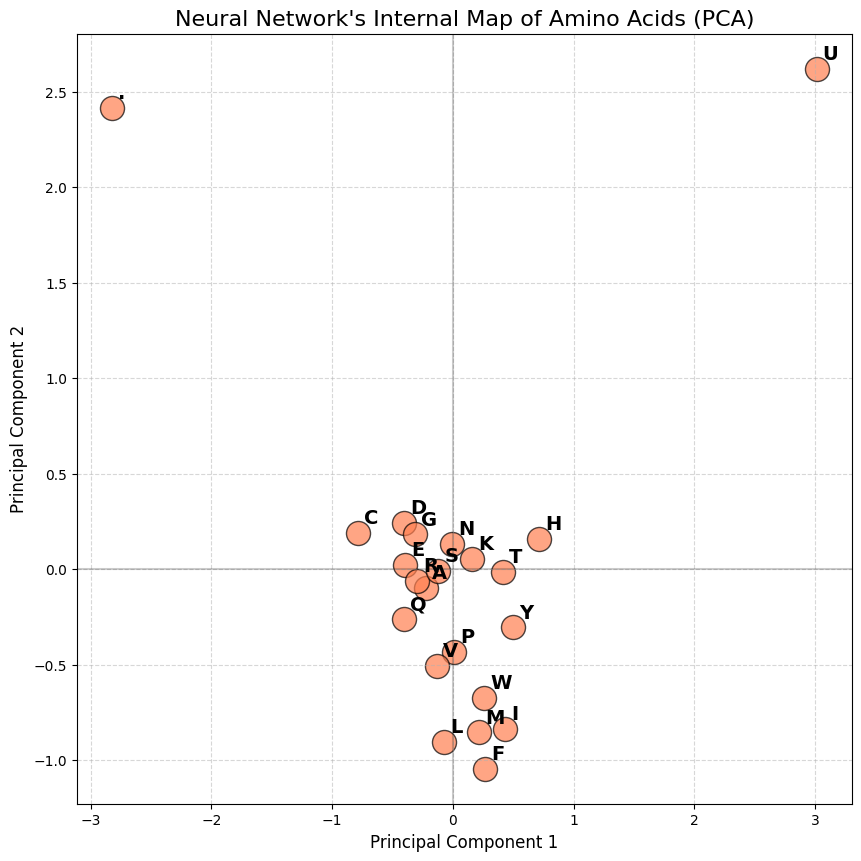

In [29]:
#Embedding graph
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

embeddings = C.detach().cpu().numpy()

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 10))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=300, c='coral', edgecolors='black', alpha=0.7)

for i in range(len(itos)):
    plt.text(embeddings_2d[i, 0] + 0.05,
             embeddings_2d[i, 1] + 0.05,
             itos[i],
             fontsize=14,
             fontweight='bold')

plt.title("Neural Network's Internal Map of Amino Acids (PCA)", fontsize=16)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.2)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.2)
plt.show()

In [30]:
#Sample

block_size = 10

for _ in range(20):

    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.reshape(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

MCLALAELLVYKDLARESFLTKSCEKITNPMSRLAFSQDDPSFRSAEGTTPRENDSPVFRQQMFSHLSSSYFSGSGSSSKMRSGSDIFFVTDTMLDGNQPQTLEQLFILALLQGLRRFLERLRGHKNLTNTQQLNENEVEVEEAFSNGDCVPEGANGRYSLTSKDDIKTTVV.
MATDVSAHPASESLSAGIKVELISSLLNHDVGLQSPRGYAHHVGIISHRPLRLLGMVARPGPGATQLRLVVKSTEMAGSIPSEALEVKPHPESANPKIKSGKERANMLSLLKMEKMKNLKQCLTEVFQNLHGSSSKSSLEMYPRKNTLEQEMETLADIERQKEEQEREANPYLDMEELPLCNPLLLMGYFLSVKDVKNGLLEKNCFPNQSCCYRLSPSLGGQLWPIDFGYTIAKLKEYDFFQKFSSSFTSLLTPPTQEVAVSVE.
MGGGPSPTWQSEKPHHPEMFSLVIMEGGLAAETNSLLPATDETPRIDTHQLYTEVKCRNLLIGLRWLTLDFLGLSSIGYTLWKSPFYIQRGAAVTGSYVVEESICDKPFKDPIYVKDAVAAARVLARERASRLVERLRDVQTNLGRAHWTYLITPRLASDFELKKAHEDLIIRMRSLLGVSLDYITGFAEHKSNRVKQKLLDSVPEEPESVGTQPLTLIKKSCNDDLPKTGQSEIQGIQSACLECGLEKEHRYALWPGAVCGLFRTCGWDFTQEEIENKVNSEESSSEPAGGAGAFQGPSPYMEPKGPGEVLTQQALQANPITDAVLDLPDIHFPNTELVTALGKGVTGAGGQPLASRVRHLIDHPSALPPSTSSHTATEIHKFHEDFPCLRYRGWIDGDFLPPGETSCIYLGTGDEQDKLEEEVEEIFFQRILDESIKTNLEFGLPRYMRSKMVYSHANAEDNERRKLKIMGFVGQDGMGALSLKLSKNGKILYPLLQLAGRPVGAPERAARLGPPGPPGLFGKACLDNRSICMPHTTKLSDLLGHAQNKCKIPPEFYI

In [31]:
test_loss = evaluate_split(X_test, Y_test)
print(f'Test Loss: {test_loss:.4f}')

Test Loss: 2.8371
